# Univariate LSTM model (B)

**Directly predict *near-term* volatility (only) from historical return and volatility.**

Author: Pete King

This notebook uses financial data to train a univariate Long Short-Term Memory (LSTM) model to predict ***near-term*** **volatility** for a single of ETF representing a market sector, using only the ETF's historical return and volatility as input.

The purpose of this notebook is to establish a baseline for an LSTM's ability to predict the next value in a financial time series using limited input.  Subsequent multivariate LSTM models will incorporate additional features, and we will compare performance to asses the degree to which additional features help or hinder a model's ability to predict future financial performance.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_etf_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_etf_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 5  # No. observations in each input sequence to LSTM
BATCH_SIZE = 21  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
data_cols = [TICKER + '_ret', TICKER + '_h-vol']
label_col = [TICKER + '_f-vol_target']
train_df[data_cols + label_col]

,SPY_ret,SPY_h-vol,SPY_f-vol_target
date,,,
2004-11-26,-0.000760,0.005587,0.005482
2004-11-29,-0.004573,0.003227,0.005089
2004-11-30,0.000678,0.002444,0.006581
2004-12-01,0.011303,0.005573,0.004954
2004-12-02,0.000838,0.005485,0.005186
...,...,...,...
2022-12-19,-0.008516,0.013601,0.009769
2022-12-20,0.001367,0.013190,0.011240
2022-12-21,0.014842,0.014485,0.012080


In [3]:
val_df[data_cols + label_col]

,SPY_ret,SPY_h-vol,SPY_f-vol_target
date,,,
2023-01-03,-0.004219,0.010149,0.012281
2023-01-04,0.007690,0.010569,0.013061
2023-01-05,-0.011479,0.010334,0.012119
2023-01-06,0.022673,0.012081,0.006860
2023-01-09,-0.000567,0.012026,0.006905
...,...,...,...
2024-09-17,0.000409,0.006388,0.007906
2024-09-18,-0.002970,0.004662,0.007856
2024-09-19,0.016920,0.008057,0.002754


## II. PyTorch Multivariate LSTM Model

In this section we use the PyTorch library to create Datasets and DataLoaders that we will use to introduce training samples to the LSTM model in batches.

We use a custom Dataset for time series data.  The Dataset implements a rolling window that captures a series of data points from time (t - L) to time (t - 1), where L is the size of the rolling window (i.e., sequence length).  Thus each data sample is a matrix with dimensions (num_features, L), where num_features is the number of features in each data instance.

Our goal is to predict future volatility, but what remains unknown is how far into the future we should try to predict.  In this investigation, we will vary the size of the future-looking window for volatility and examine the empirical results.

### Create Datasets and DataLoaders

For the initial investigation, we try to predict the *current day's volatility* using past observations.

*Note: PyTorch LSTM models require input to use datatype 'np.float32'*

In [4]:
X_train = train_df.dropna()[data_cols]
y_train = train_df.dropna()[label_col]
X_val = val_df.dropna()[data_cols]
y_val = val_df.dropna()[label_col]
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([5, 2])
Shape of first training label: torch.Size([1])


In [6]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([21, 5, 2])
Shape of first batch of labels: torch.Size([21, 1])


### Instantiate and train LSTM model

In [7]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 32  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [8]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [9]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(2, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [10]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [11]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.00356216705404222
Validation loss: 0.0036333692260086536
Epoch 20
Training loss:   0.001812809961847961
Validation loss: 0.001110764336772263
Epoch 30
Training loss:   0.0016493774019181728
Validation loss: 0.0012016399996355176
Epoch 40
Training loss:   0.0016095370519906282
Validation loss: 0.0012337482767179608
Epoch 50
Training loss:   0.0016960024368017912
Validation loss: 0.001270732027478516
Epoch 60
Training loss:   0.0015835101949051023
Validation loss: 0.001134467194788158
Epoch 70
Training loss:   0.001592534827068448
Validation loss: 0.0011359964264556766
Epoch 80
Training loss:   0.001599860843271017
Validation loss: 0.001207837020047009
Epoch 90
Training loss:   0.0015858124243095517
Validation loss: 0.0011562044965103269
Epoch 100
Training loss:   0.0015768087469041348
Validation loss: 0.0011548661859706044


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


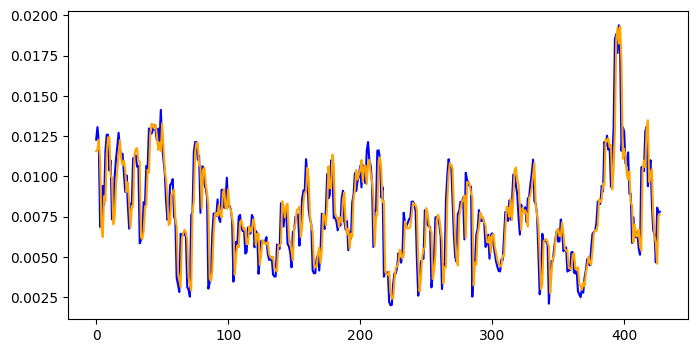

In [12]:
fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')

These results look promising!  Starting to believe we are on the right track with predicting volatility.  With some tuning we may be able to improve results.

I have serious doubts about using historical returns to predict future returns, however.  For now I think we should focus on predicting volatility.